<a href="https://colab.research.google.com/github/Mounir-Barakat/heart-disease-risk-prediction-model/blob/main/Heart_Disease_Risk_Prediction_Model_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df = pd.read_csv(url)

In [32]:
# Show first 5 rows
print(df.head())
print("Dataset shape:", df.shape)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
Dataset shape: (303, 14)


In [33]:
# Prepare the data
X = df.drop('target', axis=1)  # Everything except target
y = df['target']                # What we want to predict

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Build and train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Test the model
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Training samples: 242
Testing samples: 61
Model Accuracy: 83.61 %


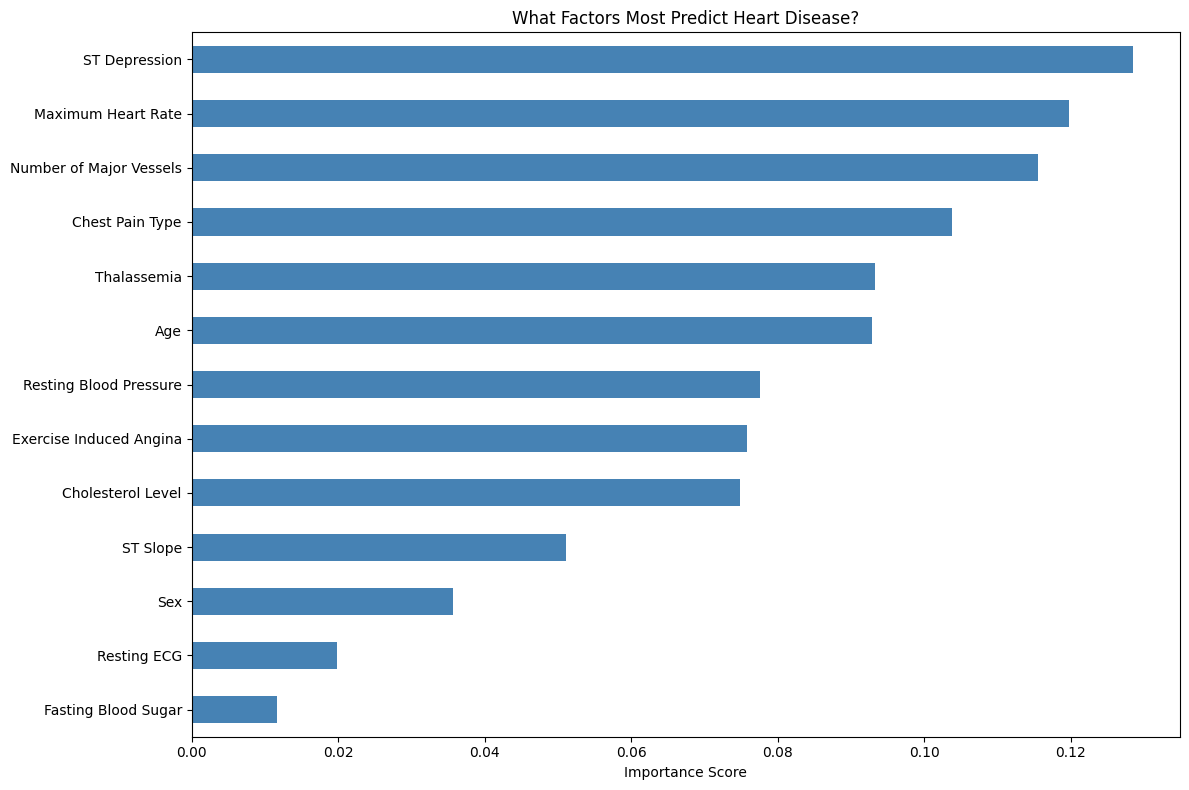

In [37]:
# Rename Column Schema
feature_names = {
    'age': 'Age',
    'sex': 'Sex',
    'cp': 'Chest Pain Type',
    'trestbps': 'Resting Blood Pressure',
    'chol': 'Cholesterol Level',
    'fbs': 'Fasting Blood Sugar',
    'restecg': 'Resting ECG',
    'thalach': 'Maximum Heart Rate',
    'exang': 'Exercise Induced Angina',
    'oldpeak': 'ST Depression',
    'slope': 'ST Slope',
    'ca': 'Number of Major Vessels',
    'thal': 'Thalassemia'
}
# Plot Graph
feature_importance = pd.Series(
    model.feature_importances_,
    index=[feature_names[col] for col in X.columns]
).sort_values(ascending=True)

plt.figure(figsize=(12,8))
feature_importance.plot(kind='barh', color='steelblue')
plt.title('What Factors Most Predict Heart Disease?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

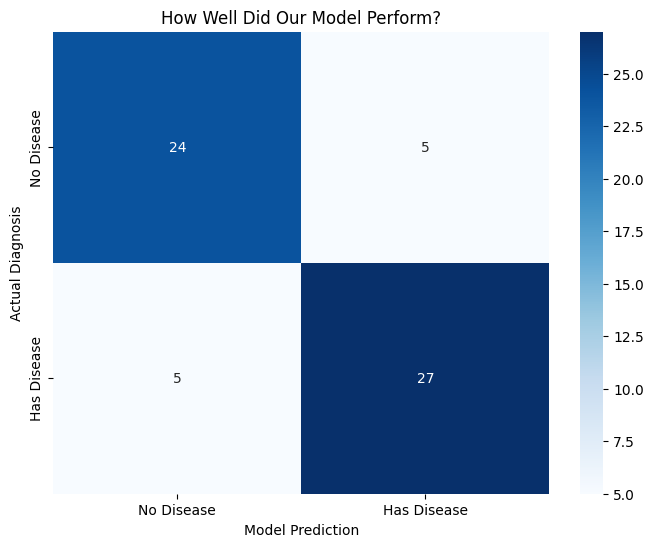

In [38]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Has Disease'],
            yticklabels=['No Disease', 'Has Disease'])
plt.title('How Well Did Our Model Perform?')
plt.ylabel('Actual Diagnosis')
plt.xlabel('Model Prediction')
plt.show()

In [41]:
#Prediction Tool
def predict_heart_disease():
    print("=== Heart Disease Prediction Tool ===\n")

    # Get patient details
    age = float(input("Patient Age: "))
    sex = float(input("Sex (1=Male, 0=Female): "))
    cp = float(input("Chest Pain Type (0-3): "))
    trestbps = float(input("Resting Blood Pressure: "))
    chol = float(input("Cholesterol Level: "))
    fbs = float(input("Fasting Blood Sugar >120mg (1=Yes, 0=No): "))
    restecg = float(input("Resting ECG (0-2): "))
    thalach = float(input("Maximum Heart Rate: "))
    exang = float(input("Exercise Induced Angina (1=Yes, 0=No): "))
    oldpeak = float(input("ST Depression (oldpeak): "))
    slope = float(input("Slope of ST Segment (0-2): "))
    ca = float(input("Number of Major Vessels (0-3): "))
    thal = float(input("Thal (1=Normal, 2=Fixed, 3=Reversible): "))

    # Make prediction
    patient_data = [[age, sex, cp, trestbps, chol, fbs,
                     restecg, thalach, exang, oldpeak,
                     slope, ca, thal]]

    prediction = model.predict(patient_data)
    probability = model.predict_proba(patient_data)

    print("\n=== Results ===")
    if prediction[0] == 1:
        print("⚠️ HIGH RISK: This patient is likely to have heart disease")
    else:
        print("✅ LOW RISK: This patient is unlikely to have heart disease")

    print(f"Confidence: {round(max(probability[0]) * 100, 2)}%")


predict_heart_disease()

=== Heart Disease Prediction Tool ===

Patient Age: 54
Sex (1=Male, 0=Female): 0
Chest Pain Type (0-3): 3
Resting Blood Pressure: 102
Cholesterol Level: 198
Fasting Blood Sugar >120mg (1=Yes, 0=No): 0
Resting ECG (0-2): 1
Maximum Heart Rate: 158
Exercise Induced Angina (1=Yes, 0=No): 0
ST Depression (oldpeak): 1.5
Slope of ST Segment (0-2): 0
Number of Major Vessels (0-3): 2
Thal (1=Normal, 2=Fixed, 3=Reversible): 1

=== Results ===
⚠️ HIGH RISK: This patient is likely to have heart disease
Confidence: 62.0%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
